In [1]:
import numpy as np
import matplotlib.pyplot as plt

from src.config import SimulationConfig
from src.field import ElectricField

In [2]:
config = SimulationConfig(
    nx=128,
    ny=128,
    voltage=1.0,
    tolerance=1e-5,
    max_iterations=50_000,
    needle_length=0.0,
    needle_width=0.0,
)

In [3]:
field = ElectricField(config)
iterations, error = field.solve_laplace_sor_numba()

print("Iterations:", iterations)
print("Error:", error)

Iterations: 10
Error: 3.774758283725532e-15


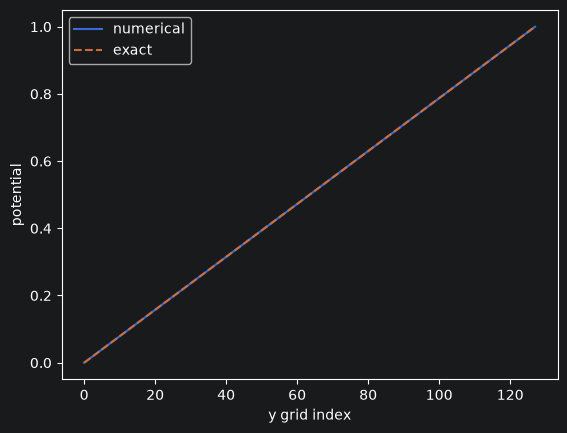

Max error from exact solution: 2.220446049250313e-15


In [4]:
x_center = config.nx // 2

phi_numerical = field.phi[:, x_center]
phi_exact = np.linspace(
    0.0,
    config.voltage,
    config.ny
)
plt.plot(phi_numerical, label="numerical")
plt.plot(phi_exact, "--", label="exact")

plt.xlabel("y grid index")
plt.ylabel("potential")
plt.legend()
plt.show()
max_error = np.max(
    np.abs(phi_numerical - phi_exact)
)

print("Max error from exact solution:", max_error)

In [5]:
Ex, Ey, E = field.electric_field()

print("Mean Ex:", np.mean(Ex))
print("Mean Ey:", np.mean(Ey))
print("Mean |E|:", np.mean(E))

Mean Ex: 2.839932065554218e-17
Mean Ey: -1.0
Mean |E|: 1.0


In [6]:
field = ElectricField(config)

x0 = config.nx // 2
channel_length = 35

In [7]:
field.channel[:channel_length, x0] = True
field.apply_boundary_conditions()
iterations, error = field.solve_laplace_sor_numba()

print("Iterations:", iterations)
print("Error:", error)

Iterations: 340
Error: 8.496096664256658e-06


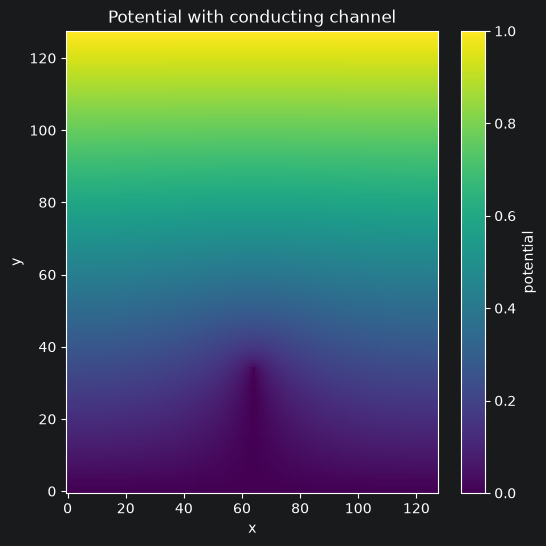

In [8]:
plt.figure(figsize=(6, 6))

plt.imshow(
    field.phi,
    origin="lower",
    aspect="auto"
)

plt.colorbar(label="potential")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Potential with conducting channel")

plt.show()

In [9]:
Ex, Ey, E = field.electric_field()
E_plot = E.copy()
E_plot[field.channel] = np.nan

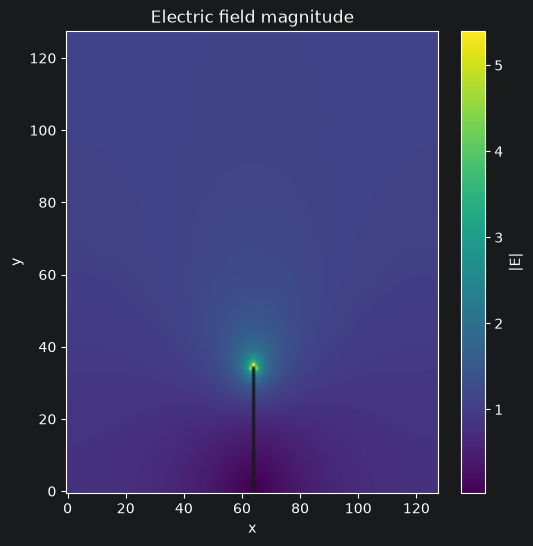

In [10]:
plt.figure(figsize=(6, 6))

plt.imshow(
    E_plot,
    origin="lower",
    aspect="auto"
)

plt.colorbar(label="|E|")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Electric field magnitude")

plt.show()

In [11]:
E0 = config.voltage / config.ly
tip_y = channel_length - 1
tip_x = x0
E_tip = E[tip_y + 1, tip_x]

print("Background field:", E0)
print("Field near tip:", E_tip)
print("Enhancement:", E_tip / E0)

Background field: 1.0
Field near tip: 5.397807483963807
Enhancement: 5.397807483963807


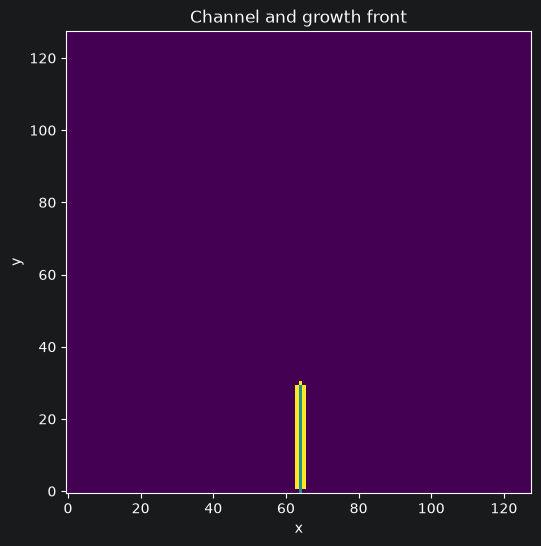

(59, 2)
[[ 1 63]
 [ 1 65]
 [ 2 63]
 [ 2 65]
 [ 3 63]
 [ 3 65]
 [ 4 63]
 [ 4 65]
 [ 5 63]
 [ 5 65]]
Number of candidates: 59
Number of field values: 59
[0.04793614 0.04788626 0.07590146 0.07582261 0.10764562 0.10753419
 0.14093319 0.1407881  0.17523165 0.1750525 ]


In [12]:
from src.growth import get_front

field = ElectricField(config)
x0 = config.nx // 2
channel_length = 30
field.channel[:channel_length, x0] = True

field.apply_boundary_conditions()
field.solve_laplace_sor_numba()

front = get_front(field.channel)
image = np.zeros(
    (config.ny, config.nx)
)

image[field.channel] = 1
image[front] = 2

plt.figure(figsize=(6, 6))

plt.imshow(
    image,
    origin="lower",
    aspect="auto"
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Channel and growth front")

plt.show()

candidates = np.argwhere(front)
print(candidates.shape)
print(candidates[:10])
Ex, Ey, E = field.electric_field()
field_on_front = E[front]
print("Number of candidates:", len(candidates))
print("Number of field values:", len(field_on_front))
print(field_on_front[:10])

In [13]:
from src.growth import get_front, get_growth_probabilities
front = get_front(field.channel | field.needle)
Ex, Ey, E = field.electric_field()
strength = np.ones_like(E)
probabilities = get_growth_probabilities(
    E,
    strength,
    front,
    config.eta,
    config.mean_breakdown_field,
)
print("Number of probabilities:", len(probabilities))
print("Sum:", probabilities.sum())

print("Min probability:", probabilities.min())
print("Max probability:", probabilities.max())

Number of probabilities: 59
Sum: 1.0
Min probability: 0.0
Max probability: 0.1564595744748812


In [14]:
from src.growth import (
    get_front,
    get_growth_probabilities,
    choose_growth_cell,
)
rng = np.random.default_rng(42)
front = get_front(field.channel | field.needle)

Ex, Ey, E = field.electric_field()

candidates = np.argwhere(front)

probabilities = get_growth_probabilities(
    E,
    strength,
    front,
    config.eta,
    config.mean_breakdown_field,
)
next_cell = choose_growth_cell(
    candidates,
    probabilities,
    rng
)

print(next_cell)
y, x = next_cell
field.channel[y, x] = True

[29 65]


In [15]:
from src.growth import growth_step

field = ElectricField(config)
field.channel[0, config.nx // 2] = True
rng = np.random.default_rng(42)
strength = np.ones((config.ny, config.nx))

for step in range(20):
    cell = growth_step(
        field,
        strength,
        config.eta,
        config.mean_breakdown_field,
        rng,
    )

    print(step, cell)

0 [ 1 64]
1 [ 2 64]
2 [ 3 64]
3 [ 4 64]
4 [ 3 65]
5 [ 5 64]
6 [ 6 64]
7 [ 7 64]
8 [ 6 63]
9 [ 7 63]
10 [ 7 65]
11 [ 8 65]
12 [ 8 66]
13 [ 9 66]
14 [ 9 65]
15 [ 8 64]
16 [ 9 67]
17 [ 7 62]
18 [10 66]
19 [10 67]


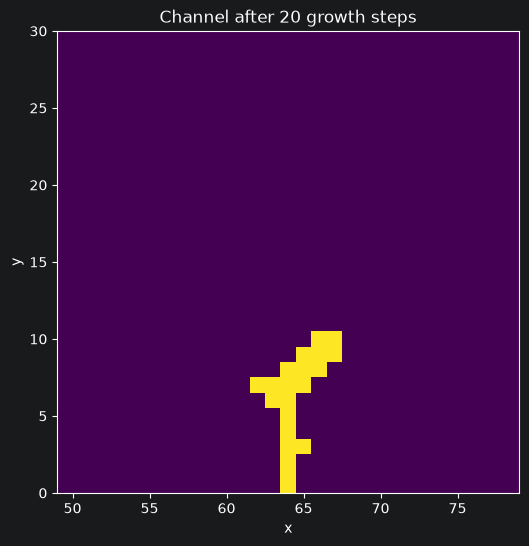

In [16]:
plt.figure(figsize=(6, 6))

plt.imshow(
    field.channel,
    origin="lower",
    aspect="equal"
)

plt.xlim(config.nx // 2 - 15, config.nx // 2 + 15)
plt.ylim(0, 30)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Channel after 20 growth steps")

plt.show()

Breakdown: True
Growth steps: 367


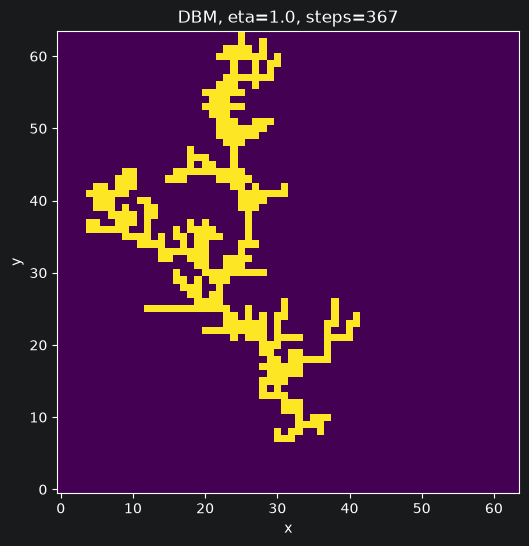

In [17]:
from src.simulator import run_simulation
config = SimulationConfig(
    nx=64,
    ny=64,
    voltage=1.0,
    tolerance=1e-5,
    max_iterations=50_000,
    eta=1.0,
    max_growth_steps=3000,
    random_seed=42,
)
field, history, breakdown = run_simulation(config)

print("Breakdown:", breakdown)
print("Growth steps:", len(history))
plt.figure(figsize=(6, 6))

plt.imshow(
    field.channel,
    origin="lower",
    aspect="equal"
)

plt.xlabel("x")
plt.ylabel("y")
plt.title(
    f"DBM, eta={config.eta}, steps={len(history)}"
)

plt.show()
